In [2]:
import numpy as np
import pandas as pd
import math as math
from scipy import optimize
import matplotlib.pylab as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
# %matplotlib widget
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

from MoorLib import moorSeg
from MoorLib import moorLine2D
from MoorLib import moorLine3D


In [3]:
g = 9.81
Wpm = 376
lineAng = [0,180]  # Angles 
flDist = 14
lineDist_ratio = 0.84  # Ratio of lineDist to lineLength

# Define rows: each row has (y_offset, depth, lineLength)
# y_offset: position in y-direction (every 50 units)
# depth: water depth for this row
# lineLength: mooring line length for this row
rows = [
    {'y_offset': 1500,    'depth': 37.5,  'lineLength': 100},    
    {'y_offset': 4500,   'depth': 72.5,  'lineLength': 200},
    {'y_offset': 10500,  'depth': 52.5,  'lineLength': 150},
    {'y_offset': 21000,  'depth': 22.5,  'lineLength': 40}
]
Mooring_spacing = 50
lengths = np.array([3000,3000,9000,12000])
lengths_times_angles = np.repeat(lengths, len(lineAng))/Mooring_spacing




In [4]:
# Create mooring segments and lines for all rows
lineMat = []
rowInfo = []  # Track which row each line belongs to

# Iterate through each row
for row_idx, row in enumerate(rows):
    y_offset = row['y_offset']
    depth = row['depth']
    lineLength = row['lineLength']
    lineDist = lineDist_ratio * lineLength
    
    # Create segment for this row
    segMat = [moorSeg(LTot=lineLength, Wpm=Wpm, EA=1861000000)]
    
    # Create mooring lines at each angle for this row
    for iAng in lineAng:
        xan = lineDist * np.cos(iAng * np.pi / 180.0)
        yan = y_offset + lineDist * np.sin(iAng * np.pi / 180.0)
        
        iLine = moorLine3D(xan, yan, -depth, seg=segMat)
        
        # Solve for fairlead position
        xfl = flDist * np.cos(iAng * np.pi / 180.0)
        yfl = y_offset + flDist * np.sin(iAng * np.pi / 180.0)
        zfl = 0.0
        
        iLine.solveFl_xyz(xfl, yfl, zfl)
        
        lineMat.append(iLine)
        rowInfo.append({'row': row_idx, 'angle': iAng, 'depth': depth, 'lineLength': lineLength})

# Calculate total forces at all fairleads
Fx = sum([iLine.retFlForce()[0] for iLine in lineMat])
Fy = sum([iLine.retFlForce()[1] for iLine in lineMat])
Fz = sum([iLine.retFlForce()[2] for iLine in lineMat])

Fzz = []
F = 0
for iLine in lineMat:
    Fzz.append(iLine.retFlForce()[2])
for index, length in enumerate(lengths_times_angles):
    F += Fzz[index] * length
print(f'The total vertical force of the system, interpoloated between the mooring points, is {(F/10**6):.2f} MN')    

print(f"Total system forces: Fx = {Fx:.2f}, Fy = {Fy:.2f}, Fz = {(Fz/1000):.2f} kN\n")

# Print characteristics for each line
Vertical_force = []
for i, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    # print(f"Line {i} (Row {info['row']}, Angle {info['angle']}°, Depth {info['depth']}m):")
    Vertical_force.append(iLine.l2d.Ve)
    # print(f"  Total length: {iLine.retLTot():.2f}, "
    #       f"Suspended: {iLine.retLSusp():.2f}, "
    #       f"Bed: {iLine.retLBed():.2f}, "
    #       f"H0: {iLine.l2d.H0:.2f}, "
    #       f"VEnd: {iLine.l2d.Ve:.2f}\n")


# print(Vertical_force)

    
# Save the stable solution for each line
for iLine in lineMat:
    iLine.setRef_FLxyz(iLine.xfl, iLine.yfl, iLine.zfl)
    iLine.setRef_H(iLine.retFlForce_H())
    iLine.setRef_LBed(iLine.retLBed())


The total vertical force of the system, interpoloated between the mooring points, is -178.92 MN
Total system forces: Fx = 0.00, Fy = 0.00, Fz = -1581.86 kN



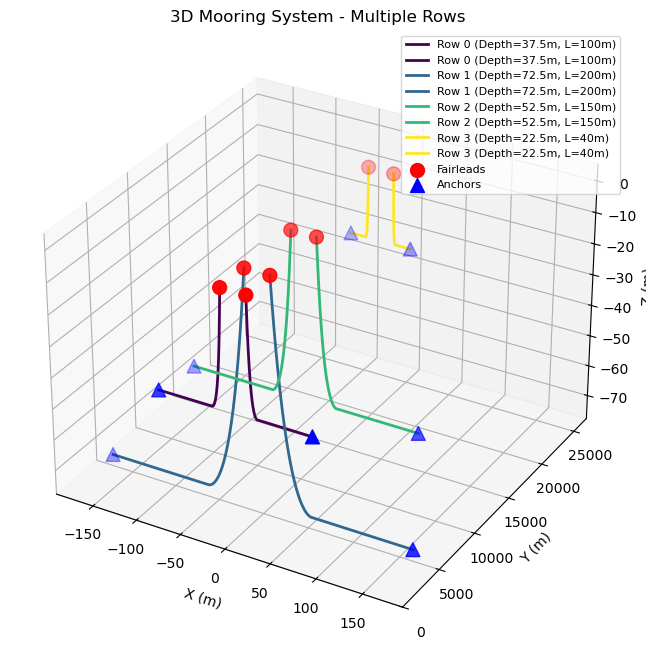

In [5]:
# Plot all mooring lines with color coding by row
plt.figure(figsize=(15, 8))
ax = plt.axes(projection='3d')

# Color map for rows
colors = plt.cm.viridis(np.linspace(0, 1, len(rows)))

# Plot lines grouped by row
for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    ax.plot(x, y, z, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")

# Plot fairleads
fairlead_x = [iLine.xfl for iLine in lineMat]
fairlead_y = [iLine.yfl for iLine in lineMat]
fairlead_z = [iLine.zfl for iLine in lineMat]
ax.scatter(fairlead_x, fairlead_y, fairlead_z, c='red', s=100, marker='o', label='Fairleads')

# Plot anchors
anchor_x = [iLine.xan for iLine in lineMat]
anchor_y = [iLine.yan for iLine in lineMat]
anchor_z = [iLine.zan for iLine in lineMat]
ax.scatter(anchor_x, anchor_y, anchor_z, c='blue', s=100, marker='^', label='Anchors')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_ylim(0, 27000)
ax.set_zlabel('Z (m)')
ax.set_title('3D Mooring System - Multiple Rows')
ax.grid(True)
ax.legend(loc='upper right', fontsize=8)
plt.show()


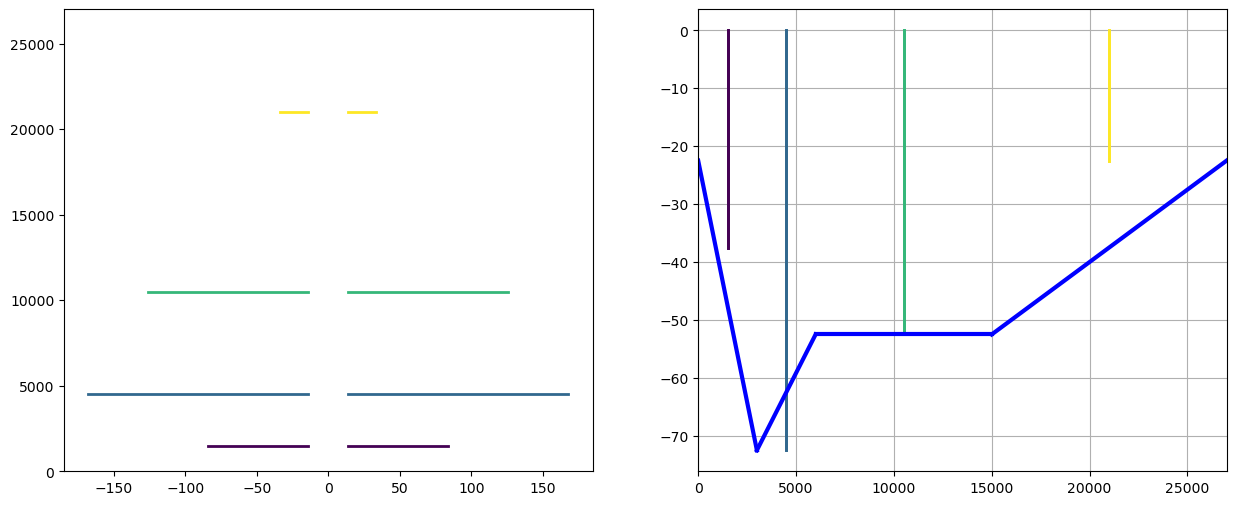

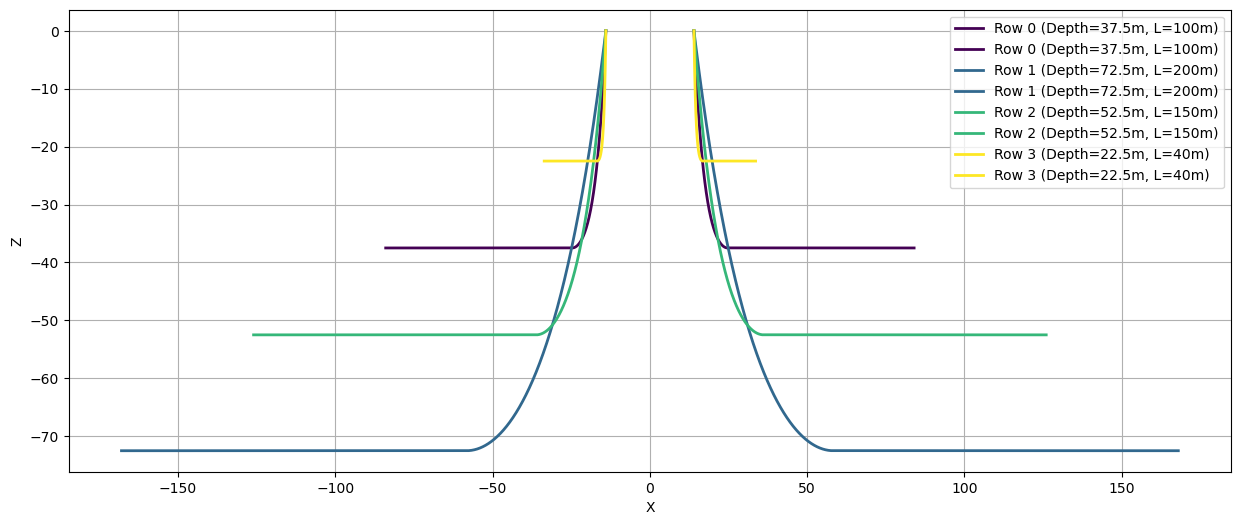

In [12]:
f, (ax1, ax2) = plt.subplots(1,2)
for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    ax1.plot(x, y, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")
ax1.set_ylim(0, 27000)
    
for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    ax2.plot(y,z, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")


x1 = np.linspace(0, 3000)
x2 = np.linspace(3000, 6000)
x3 = np.linspace(6000, 15000)
x4 = np.linspace(15000, 27000)

y1 = -22.5 -1/60 * x1
y2 = -92.5 + 1/150 * x2
y3 = -52.5 + 0*x3
y4 = 1/400*x4 - 90 


ax2.plot(x1, y1, 'b-', lw=3)
ax2.plot(x2, y2, 'b-', lw=3)
ax2.plot(x3, y3, 'b-', lw=3)
ax2.plot(x4, y4, 'b-', lw=3)
ax2.set_xlim(0, 27000)
ax2.grid()

plt.figure()
for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    plt.plot(x, z, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")
plt.xlabel('X')
plt.ylabel('Z')
plt.legend()
plt.grid()
plt.show()
